### Discharge estimation of hydrogen

In [14]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

F = 96485.3329
z = 2
Vm = 24000

DATA_DIR = Path("../../data/PEM_test")
CHARGE_DISCHARGE_DIR = DATA_DIR / "charge_discharge"
CURRENT_SWEEP_DIR = DATA_DIR / "current_sweep"

FULL_DISCHARGE_FILE = "discharge_PEM_full.csv"
CURRENT_SWEEP_FILE = "sweep_increasing_load_10s.csv"

H2_FULL_ML = 15.6
H2_LEFT_AT_COLLAPSE_ML = 7.6
H2_USABLE_ML = H2_FULL_ML - H2_LEFT_AT_COLLAPSE_ML

CURRENT_CORRECTION = {
    0x44: lambda i: i + 0.000138,
    0x45: lambda i: 0.843 * i + 0.001,
}

VOLTAGE_CORRECTION = {
    0x44: lambda v: v - 0.180,
    0x45: lambda v: v - 0.064,
}

In [15]:
def load_and_correct_file(path):
    df = pd.read_csv(path)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp").reset_index(drop=True)

    df["time_s"] = (
        df["timestamp"] - df["timestamp"].iloc[0]
    ).dt.total_seconds()

    df["dt_s"] = df["timestamp"].diff().dt.total_seconds().fillna(0)

    df["pem_current_A"] = CURRENT_CORRECTION[0x45](
        df["ina4_current_mA"] / 1000
    )

    df["pem_voltage_V"] = VOLTAGE_CORRECTION[0x45](
        df["ina4_bus_V"]
    )

    df["pem_power_W"] = (
        df["pem_voltage_V"]
        * df["pem_current_A"]
    )

    return df

In [ ]:
# We have to do the coulomb counting until end as that was
#  the point of the volume test
def extract_discharge_until_collapse(
    df,
    collapse_voltage_V=0.2,
    settling_time_s=30
):
    df = df.sort_values("timestamp").reset_index(drop=True).copy()

    high_voltage = df["pem_voltage_V"] > 1.0
    last_high_idx = high_voltage[high_voltage].index[-1]

    discharge = df.loc[last_high_idx + 1:].copy()
    discharge = discharge[discharge["scenario"] == 6].copy()
    discharge = discharge.reset_index(drop=True)

    discharge["time_discharge_s"] = (
        discharge["timestamp"] - discharge["timestamp"].iloc[0]
    ).dt.total_seconds()

    below_collapse = (
        (discharge["pem_voltage_V"] <= collapse_voltage_V)
        & (discharge["time_discharge_s"] > settling_time_s)
    )

    if below_collapse.any():
        end_idx = below_collapse.idxmax()
        discharge = discharge.loc[:end_idx].copy()

    discharge = discharge.reset_index(drop=True)

    discharge["dt_s"] = (
        discharge["timestamp"]
        .diff()
        .dt.total_seconds()
        .fillna(0)
    )

    discharge["time_discharge_s"] = (
        discharge["timestamp"] - discharge["timestamp"].iloc[0]
    ).dt.total_seconds()

    return discharge

Load full discharge and check extraction 

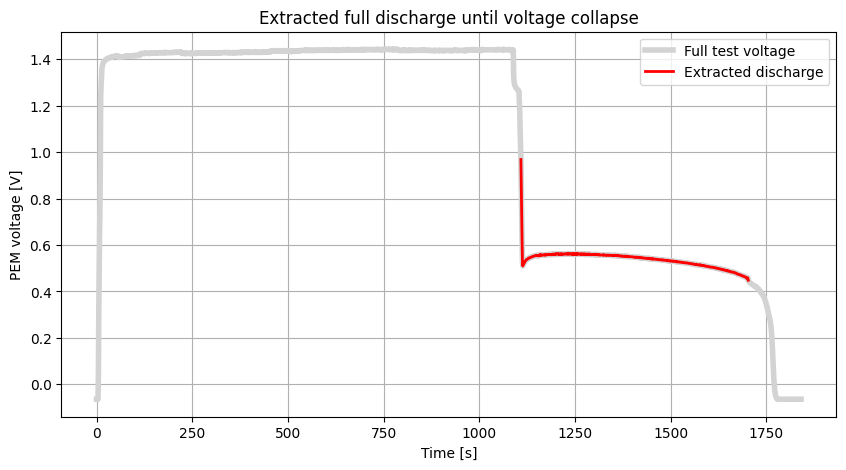

In [39]:
df_full = load_and_correct_file(
    CHARGE_DISCHARGE_DIR / FULL_DISCHARGE_FILE
)

discharge_full = extract_discharge_until_collapse(df_full)

plt.figure(figsize=(10, 5))

plt.plot(
    df_full["time_s"],
    df_full["pem_voltage_V"],
    color="lightgray",
    linewidth=4,
    label="Full test voltage"
)

plt.plot(
    discharge_full["time_s"],
    discharge_full["pem_voltage_V"],
    color="red",
    linewidth=2,
    label="Extracted discharge"
)

plt.xlabel("Time [s]")
plt.ylabel("PEM voltage [V]")
plt.title("Extracted full discharge until voltage collapse")
plt.grid(True)
plt.legend()
plt.show()

Faradays law and coulomb counting

In [40]:
I_discharge_A = abs(discharge_full["pem_current_A"])
dt_s = discharge_full["dt_s"]

Q_discharge_C = np.sum(I_discharge_A * dt_s)

H2_theoretical_mL = (
    Q_discharge_C
    / (z * F)
    * Vm
)

eta_discharge = (
    H2_USABLE_ML
    / H2_theoretical_mL
)

H2_DISCHARGE_FACTOR_ML_PER_C = (
    eta_discharge
    * Vm
    / (z * F)
)

print(f"Integrated discharge charge: {Q_discharge_C:.3f} C")
print(f"Theoretical H2 consumed: {H2_theoretical_mL:.3f} mL")
print(f"Measured usable H2: {H2_USABLE_ML:.3f} mL")
print(f"Discharge correction factor: {eta_discharge:.3f}")
print(f"Hydrogen discharge factor: {H2_DISCHARGE_FACTOR_ML_PER_C:.8f} mL/C")

print("\nEMS equation:")
print(f"H2_next_mL = H2_now_mL - {H2_DISCHARGE_FACTOR_ML_PER_C:.8f} * I_discharge_A * dt_s")

Integrated discharge charge: 28.584 C
Theoretical H2 consumed: 3.555 mL
Measured usable H2: 8.000 mL
Discharge correction factor: 2.250
Hydrogen discharge factor: 0.27987809 mL/C

EMS equation:
H2_next_mL = H2_now_mL - 0.27987809 * I_discharge_A * dt_s


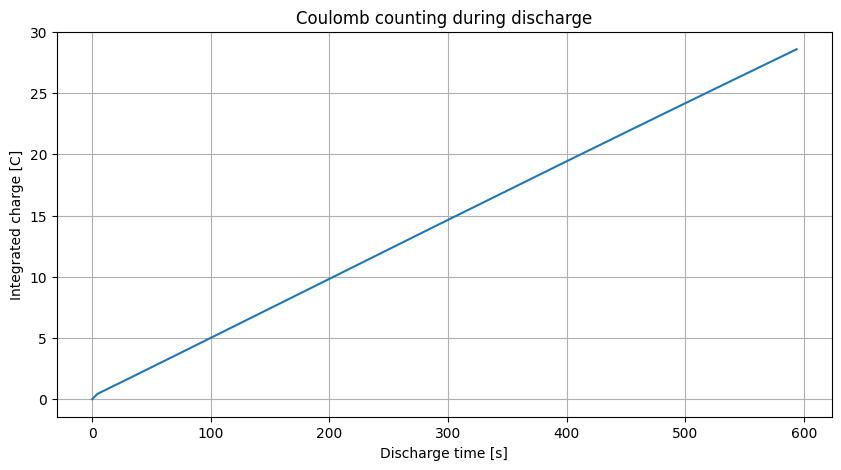

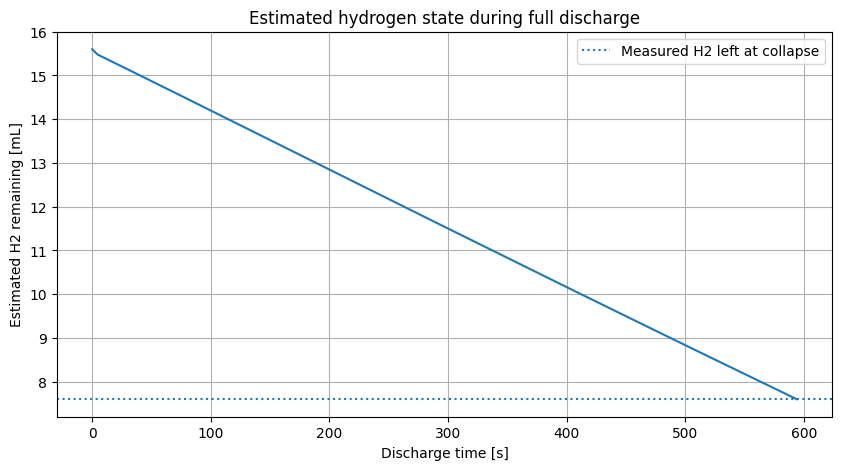

In [41]:
discharge_full["I_discharge_A"] = abs(discharge_full["pem_current_A"])

discharge_full["dQ_C"] = (
    discharge_full["I_discharge_A"]
    * discharge_full["dt_s"]
)

discharge_full["Q_C"] = discharge_full["dQ_C"].cumsum()

discharge_full["H2_used_mL"] = (
    discharge_full["Q_C"]
    * H2_DISCHARGE_FACTOR_ML_PER_C
)

discharge_full["H2_remaining_mL"] = (
    H2_FULL_ML
    - discharge_full["H2_used_mL"]
)

plt.figure(figsize=(10, 5))

plt.plot(
    discharge_full["time_discharge_s"],
    discharge_full["Q_C"]
)

plt.xlabel("Discharge time [s]")
plt.ylabel("Integrated charge [C]")
plt.title("Coulomb counting during discharge")
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    discharge_full["time_discharge_s"],
    discharge_full["H2_remaining_mL"]
)

plt.axhline(
    H2_LEFT_AT_COLLAPSE_ML,
    linestyle=":",
    label="Measured H2 left at collapse"
)

plt.xlabel("Discharge time [s]")
plt.ylabel("Estimated H2 remaining [mL]")
plt.title("Estimated hydrogen state during full discharge")
plt.grid(True)
plt.legend()
plt.show()

Validate sweep test

In [42]:
df_sweep = load_and_correct_file(
    CURRENT_SWEEP_DIR / CURRENT_SWEEP_FILE
)

discharge_sweep = extract_discharge_until_collapse(df_sweep)

discharge_sweep["I_discharge_A"] = abs(discharge_sweep["pem_current_A"])

discharge_sweep["dQ_C"] = (
    discharge_sweep["I_discharge_A"]
    * discharge_sweep["dt_s"]
)

discharge_sweep["Q_C"] = discharge_sweep["dQ_C"].cumsum()

discharge_sweep["H2_used_mL"] = (
    discharge_sweep["Q_C"]
    * H2_DISCHARGE_FACTOR_ML_PER_C
)

discharge_sweep["H2_remaining_mL"] = (
    H2_FULL_ML
    - discharge_sweep["H2_used_mL"]
)

In [43]:
# Final theoretical hydrogen consumption
H2_model_used_mL = discharge_sweep["H2_used_mL"].iloc[-1]

# Measured hydrogen usage
H2_measured_used_mL = (
    H2_FULL_ML
    - discharge_sweep["H2_remaining_mL"].iloc[-1]
)

# Absolute error
H2_error_mL = (
    H2_model_used_mL
    - H2_measured_used_mL
)

# Relative error
H2_error_percent = (
    H2_error_mL
    / H2_measured_used_mL
    * 100
)

print(f"Theoretical H2 usage: {H2_model_used_mL:.2f} mL")
print(f"Measured H2 usage:    {H2_measured_used_mL:.2f} mL")
print(f"Absolute error:       {H2_error_mL:.2f} mL")
print(f"Relative error:       {H2_error_percent:.2f} %")

Theoretical H2 usage: 5.13 mL
Measured H2 usage:    5.13 mL
Absolute error:       -0.00 mL
Relative error:       -0.00 %


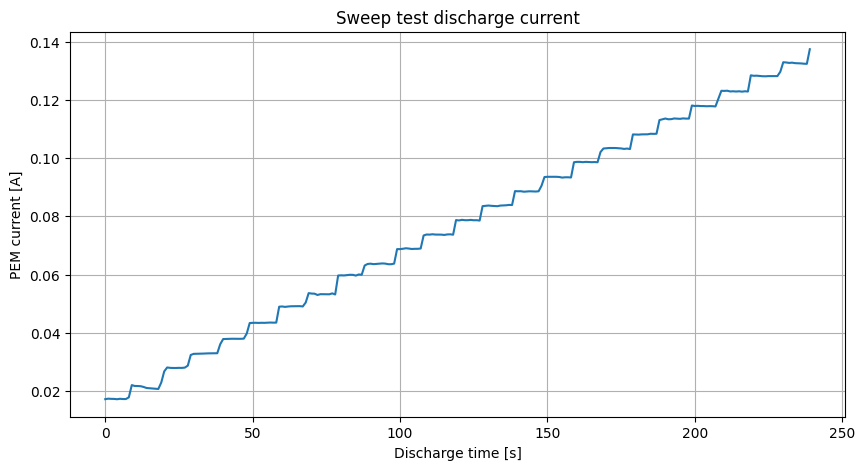

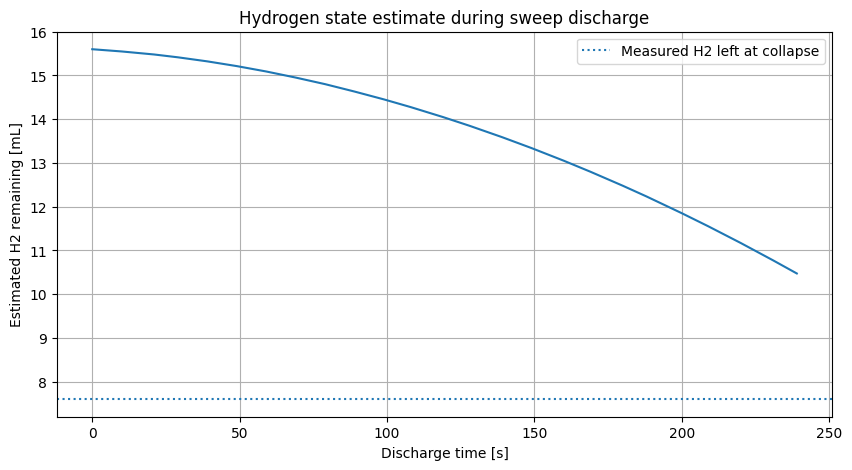

In [44]:
plt.figure(figsize=(10, 5))

plt.plot(
    discharge_sweep["time_discharge_s"],
    discharge_sweep["pem_current_A"].abs()
)

plt.xlabel("Discharge time [s]")
plt.ylabel("PEM current [A]")
plt.title("Sweep test discharge current")
plt.grid(True)
plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    discharge_sweep["time_discharge_s"],
    discharge_sweep["H2_remaining_mL"]
)

plt.axhline(
    H2_LEFT_AT_COLLAPSE_ML,
    linestyle=":",
    label="Measured H2 left at collapse"
)

plt.xlabel("Discharge time [s]")
plt.ylabel("Estimated H2 remaining [mL]")
plt.title("Hydrogen state estimate during sweep discharge")
plt.grid(True)
plt.legend()
plt.show()

The range of discharge current the rate will be valid between 

In [45]:
print(discharge_sweep["I_discharge_A"].min())
print(discharge_sweep["I_discharge_A"].max())

0.0172088
0.13735737499999998


In [46]:
def update_hydrogen_state_discharge(
    H2_now_mL,
    I_discharge_A,
    dt_s
):
    H2_next_mL = (
        H2_now_mL
        - H2_DISCHARGE_FACTOR_ML_PER_C
        * I_discharge_A
        * dt_s
    )

    H2_next_mL = np.clip(
        H2_next_mL,
        H2_LEFT_AT_COLLAPSE_ML,
        H2_FULL_ML
    )

    SoH_percent = (
        100
        * H2_next_mL
        / H2_FULL_ML
    )

    return H2_next_mL, SoH_percent